# P01 · Inspect a real anatomical template through spatial transformations

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PP01](../../curriculum/papers/processing.md#pp01), [PP04](../../curriculum/papers/processing.md#pp04).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** Which checks would make your image transformations reviewable by someone who did not run them?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Learning format:** predict → ask AI for one short operation → run → inspect → deliberately break → explain. Use Goose with a local Ollama model, or ChatGPT as a tutor and snippet writer. You are responsible for deciding whether the transformation answers the research question. Read the answer guide only after making your own prediction.

**Time:** 3–4 hours including a written audit. **Prerequisites:** processing geometry, interpolation, masks, and smoothing; DS03. **Input:** the MNI152 anatomical template packaged with Nilearn, not an individual participant. No download is required after dependencies are installed.

The project combines operations that are often hidden inside a pipeline. You will inspect physical voxel sizes, resample a continuous-valued image onto a coarser grid, apply a spatial smoothing kernel in millimeters, and resample a categorical mask with nearest-neighbor interpolation. Each operation changes a different property. Resampling evaluates an already defined image in a target grid; it does not estimate anatomical alignment. Smoothing mixes nearby values and reduces high-frequency spatial variation; it does not improve native acquisition resolution.

A template is an aggregate anatomical reference, so its clean appearance should not be mistaken for the quality of a participant scan. The attached brain mask is useful for this demonstration but is not a segmentation algorithm. It cannot establish that skull stripping or tissue classification will work on a new clinical cohort. Correct world-coordinate handling is necessary for comparison but is not sufficient evidence of biological correspondence.

Use the [Nilearn image manipulation guide](https://nilearn.github.io/stable/manipulating_images/manipulating_images.html) and its linked resampling and smoothing examples as the full upstream practical. In this original exercise you must explain the before/after change, inspect slices, and test one deliberate mistake: linearly interpolate a label mask and observe noncategorical values. Keep the continuous image and categorical mask contracts separate.

Ask the AI: **“Work one transformation at a time. Report shape, affine, voxel sizes, interpolation, and kernel units. Predict what information will be lost. Do not call grid resampling registration or treat a template mask as participant-specific segmentation.”** Save a figure and a methods paragraph with actual values, not just function names.


**Template attribution:** ICBM152 nonlinear 2009a asymmetric template, McConnell Brain Imaging Centre / MNI / McGill; Fonov et al. [2011](https://doi.org/10.1016/j.neuroimage.2010.07.033) and [2009](https://doi.org/10.1016/S1053-8119(09)70884-5). See the [source notice](../../THIRD_PARTY_NOTICES.md#anatomical-template-visualizations) for the template and displayed derivatives.


### Inspect values and physical space
Read the affine before interpreting an array index as a location.

In [1]:
import numpy as np, nibabel as nib
from nilearn.datasets import load_mni152_template, load_mni152_brain_mask
from nilearn.image import resample_img, resample_to_img, smooth_img
image = load_mni152_template(resolution=2)
mask = load_mni152_brain_mask(resolution=2)
assert image.shape == mask.shape
print('shape:',image.shape,'zooms:',image.header.get_zooms())
print('axis codes:',nib.aff2axcodes(image.affine),'affine:',image.affine,sep='\n')
assert np.allclose(image.affine,mask.affine)

shape: (99, 117, 95) zooms: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
axis codes:
('R', 'A', 'S')
affine:
[[   2.    0.    0.  -98.]
 [   0.    2.    0. -134.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]


### Coarsen the grid and smooth
Predict why a 4 mm grid contains fewer samples and why 6 mm FWHM is not a six-voxel kernel.

In [2]:
coarse = resample_img(image,target_affine=np.diag([4.,4.,4.]),interpolation='continuous',force_resample=True,copy_header=True)
smooth = smooth_img(image,fwhm=6)
mask_coarse = resample_to_img(mask,coarse,interpolation='nearest',force_resample=True,copy_header=True)
assert np.prod(coarse.shape) < np.prod(image.shape)
assert np.allclose(smooth.affine,image.affine) and smooth.shape == image.shape
assert set(np.unique(mask_coarse.get_fdata())) <= {0,1}
print('Coarse grid:',coarse.shape,'FWHM in original voxels:',6/np.array(image.header.get_zooms()[:3]))

Coarse grid: (50, 59, 48) FWHM in original voxels: [3. 3. 3.]


### Visual comparison and wrong interpolation
Inspect the template and smoothing in the same physical coordinates. Cast the mask to float for this deliberate error: integer storage can hide fractional interpolation values by rounding them.

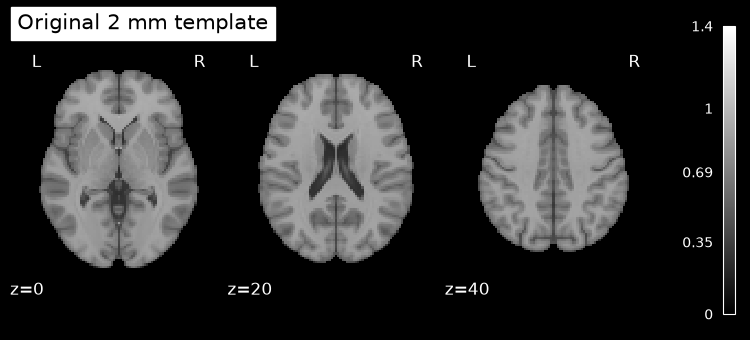

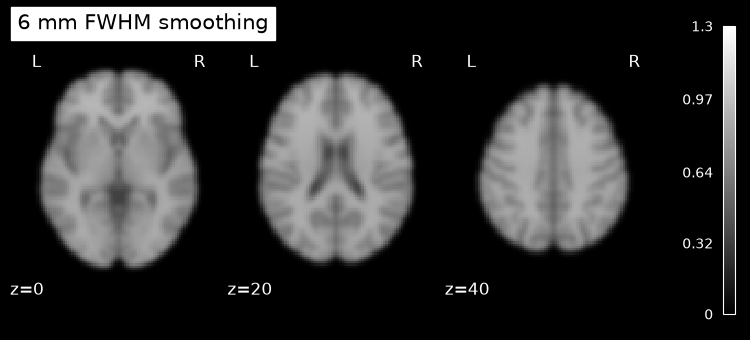

Fractional label voxels: 4103


/var/folders/y8/dwf8k50s6wx4_gv646tmfh9w0000gn/T/ipykernel_84555/2189975369.py:8: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  fractional = resample_img(float_mask,target_affine=shifted_affine,target_shape=coarse.shape,interpolation='linear',force_resample=True,copy_header=True)


In [3]:
from nilearn.plotting import plot_anat
import matplotlib.pyplot as plt
plot_anat(image,display_mode='z',cut_coords=[0,20,40],title='Original 2 mm template')
plot_anat(smooth,display_mode='z',cut_coords=[0,20,40],title='6 mm FWHM smoothing')
plt.show()
shifted_affine = coarse.affine.copy(); shifted_affine[:3,3] += 1
float_mask = nib.Nifti1Image(mask.get_fdata().astype(float),mask.affine)
fractional = resample_img(float_mask,target_affine=shifted_affine,target_shape=coarse.shape,interpolation='linear',force_resample=True,copy_header=True)
v = fractional.get_fdata()
print('Fractional label voxels:',int(((v>0)&(v<1)).sum()))
assert ((v>0)&(v<1)).any()

## Explain without AI

Submit a three-panel comparison, a transformation manifest, and an explanation of why the same shape does not imply the same space. Repeat using 3 mm and 5 mm target spacing. Keep smoothing fixed in millimeters and predict the voxel-unit kernel change.

<details><summary>Answer guide</summary>Nearest-neighbor interpolation preserves mask labels, though boundaries and voxel counts can change. Continuous interpolation is appropriate for intensities but creates fractional categorical labels. Smoothing preserves this image's grid while changing values. No registration transform or participant-specific segmentation was estimated.</details>

**Submission:** record the input, operation, parameters, output, one preserved property, one lost property, and the evidence that would make you reject the result. Include the prompt and any corrections you made to the generated code. A saved answer is not evidence of understanding until you can defend it orally.


### Return to the research question

Reopen [PP01](../../curriculum/papers/processing.md#pp01), [PP04](../../curriculum/papers/processing.md#pp04) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
